In [2]:
!pip install polars xgboost lightgbm shap imbalanced-learn groq plotly seaborn pyarrow

In [3]:
import polars as pl
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pickle, os, warnings
from pathlib import Path
from datetime import datetime
import pyarrow

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_fscore_support,
    precision_recall_curve, average_precision_score, f1_score
)
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours

warnings.filterwarnings('ignore')
Path("outputs/plots").mkdir(parents=True, exist_ok=True)
Path("outputs/models").mkdir(parents=True, exist_ok=True)
Path("outputs/reports").mkdir(parents=True, exist_ok=True)

print("✅ Imports OK  |  XGB:", xgb.__version__, " | LGB:", lgb.__version__, " | Polars:", pl.__version__)

✅ Imports OK  |  XGB: 3.2.0  | LGB: 4.6.0  | Polars: 1.39.3


In [4]:
DATA_DIR    = "data/r4.2"
ANSWERS_DIR = "answers"
DATE_FMT    = "%m/%d/%Y %H:%M:%S"

logon  = pl.read_csv(f"{DATA_DIR}/logon.csv",  infer_schema_length=10000)
file   = pl.read_csv(f"{DATA_DIR}/file.csv",   infer_schema_length=10000)
device = pl.read_csv(f"{DATA_DIR}/device.csv", infer_schema_length=10000)
email  = pl.read_csv(f"{DATA_DIR}/email.csv",  infer_schema_length=10000)
http   = pl.read_csv(f"{DATA_DIR}/http.csv",   infer_schema_length=10000)

for name, df in [("logon", logon), ("file", file), ("device", device), ("email", email), ("http", http)]:
    print(f"  {name}: {len(df):>10,} rows | cols: {df.columns}")

  logon:    854,859 rows | cols: ['id', 'date', 'user', 'pc', 'activity']
  file:    445,581 rows | cols: ['id', 'date', 'user', 'pc', 'filename', 'content']
  device:    405,380 rows | cols: ['id', 'date', 'user', 'pc', 'activity']
  email:  2,629,979 rows | cols: ['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size', 'attachments', 'content']
  http: 28,434,423 rows | cols: ['id', 'date', 'user', 'pc', 'url', 'content']


In [5]:
def preprocess(df):
    df = df.with_columns([
        pl.col("date").str.strptime(pl.Datetime, DATE_FMT, strict=False).alias("dt"),
        pl.col("user").str.strip_chars().str.to_uppercase().alias("user"),
    ])
    return df.with_columns([
        pl.col("dt").dt.date().alias("date_only"),
        pl.col("dt").dt.hour().alias("hour"),
        pl.col("dt").dt.weekday().alias("weekday"),
        (pl.col("dt").dt.weekday() >= 5).cast(pl.Int32).alias("is_weekend"),
        ((pl.col("dt").dt.hour() < 8) | (pl.col("dt").dt.hour() >= 18)).cast(pl.Int32).alias("is_after_hours"),
    ])

logon  = preprocess(logon)
file   = preprocess(file)
device = preprocess(device)
email  = preprocess(email)
http   = preprocess(http)

print("Date range:", logon["date_only"].min(), "→", logon["date_only"].max())
print("Unique users:", logon["user"].n_unique())

Date range: 2010-01-02 → 2011-05-17
Unique users: 1000


In [6]:
insiders_raw = pl.read_csv(f"{ANSWERS_DIR}/insiders.csv", infer_schema_length=1000)
print("Columns:", insiders_raw.columns)
print(insiders_raw.head(5))

insiders_raw = insiders_raw.with_columns(
    pl.col("user").str.strip_chars().str.to_uppercase().alias("user")
)

# Parse dates if start/end columns exist
if "start" in insiders_raw.columns:
    insiders_raw = insiders_raw.with_columns([
        pl.col("start").str.strptime(pl.Datetime, DATE_FMT, strict=False).dt.date().alias("start_date"),
        pl.col("end").str.strptime(pl.Datetime, DATE_FMT, strict=False).dt.date().alias("end_date"),
    ])

# Filter r4.2 if 'dataset' column present
if "dataset" in insiders_raw.columns:
    insiders = insiders_raw.filter(pl.col("dataset").cast(pl.Utf8).str.contains("4.2"))
else:
    insiders = insiders_raw

insider_users = set(insiders["user"].to_list())
print(f"\nInsider users: {len(insider_users)}")
print("Sample:", sorted(list(insider_users))[:10])

Columns: ['dataset', 'scenario', 'details', 'user', 'start', 'end']
shape: (5, 6)
┌─────────┬──────────┬────────────┬─────────┬─────────────────────┬─────────────────────┐
│ dataset ┆ scenario ┆ details    ┆ user    ┆ start               ┆ end                 │
│ ---     ┆ ---      ┆ ---        ┆ ---     ┆ ---                 ┆ ---                 │
│ f64     ┆ i64      ┆ str        ┆ str     ┆ str                 ┆ str                 │
╞═════════╪══════════╪════════════╪═════════╪═════════════════════╪═════════════════════╡
│ 2.0     ┆ 1        ┆ r2.csv     ┆ ONS0995 ┆ 3/6/2010 1:41:56    ┆ 3/20/2010 8:10:12   │
│ 3.1     ┆ 1        ┆ r3.1-1.csv ┆ CSF0929 ┆ 07/01/2010 01:24:58 ┆ 07/16/2010 06:52:00 │
│ 3.1     ┆ 2        ┆ r3.1-2.csv ┆ CCH0959 ┆ 08/02/2010 10:34:31 ┆ 09/30/2010 15:04:03 │
│ 3.2     ┆ 1        ┆ r3.2-1.csv ┆ RCW0822 ┆ 09/29/2010 21:10:27 ┆ 10/15/2010 06:34:52 │
│ 3.2     ┆ 2        ┆ r3.2-2.csv ┆ JCE0258 ┆ 07/12/2010 08:16:02 ┆ 09/03/2010 16:16:29 │
└─────────┴───────

In [7]:
logon_agg = logon.group_by(["user","date_only"]).agg([
    pl.len().alias("logon_count"),
    pl.col("pc").n_unique().alias("unique_pcs"),
    pl.col("is_after_hours").sum().alias("logon_after_hours"),
    pl.col("is_weekend").max().alias("logon_weekend"),
    pl.col("hour").mean().alias("logon_mean_hour"),
    pl.col("hour").std().alias("logon_std_hour"),
])
print("Logon agg:", logon_agg.shape)

Logon agg: (330452, 8)


In [8]:
file_enriched = file
if "activity" in file.columns:
    file_enriched = file.with_columns([
        pl.col("activity").str.contains("(?i)copy").cast(pl.Int32).alias("is_copy"),
        pl.col("activity").str.contains("(?i)delete").cast(pl.Int32).alias("is_delete"),
        pl.col("activity").str.contains("(?i)write|open").cast(pl.Int32).alias("is_write"),
    ])

file_agg = file_enriched.group_by(["user","date_only"]).agg(
    [pl.len().alias("file_count"),
     pl.col("filename").n_unique().alias("unique_files"),
     pl.col("is_after_hours").sum().alias("file_after_hours")]
    + ([pl.col("is_copy").sum().alias("file_copy"),
        pl.col("is_delete").sum().alias("file_delete"),
        pl.col("is_write").sum().alias("file_write")]
       if "activity" in file.columns else
       [pl.lit(0).alias("file_copy"), pl.lit(0).alias("file_delete"), pl.lit(0).alias("file_write")])
)
print("File agg:", file_agg.shape)

File agg: (45907, 8)


In [9]:
dev_enriched = device
if "activity" in device.columns:
    dev_enriched = device.with_columns([
        pl.col("activity").str.contains("(?i)connect").cast(pl.Int32).alias("is_connect"),
    ])

device_agg = dev_enriched.group_by(["user","date_only"]).agg(
    [pl.len().alias("device_count"),
     pl.col("is_after_hours").sum().alias("device_after_hours")]
    + ([pl.col("is_connect").sum().alias("usb_connect")]
       if "activity" in device.columns else [pl.lit(0).alias("usb_connect")])
)
print("Device agg:", device_agg.shape)

Device agg: (55717, 5)


In [10]:
INTERNAL_DOMAIN = "dtaa.com"
email_enriched = email.with_columns([
    (~pl.col("to").str.contains(f"(?i){INTERNAL_DOMAIN}")).cast(pl.Int32).alias("is_external"),
])

email_agg = email_enriched.group_by(["user","date_only"]).agg([
    pl.len().alias("email_count"),
    pl.col("is_external").sum().alias("email_external"),
    pl.col("is_after_hours").sum().alias("email_after_hours"),
] + ([pl.col("attachments").is_not_null().cast(pl.Int32).sum().alias("email_attachments")]
     if "attachments" in email.columns else [pl.lit(0).alias("email_attachments")]))
print("Email agg:", email_agg.shape)


Email agg: (326985, 6)


In [11]:
SUSPICIOUS = "job|career|resume|linkedin|dropbox|wikileaks|torrent|rapidshare|mega"
http_enriched = http
if "url" in http.columns:
    http_enriched = http.with_columns([
        pl.col("url").str.contains(f"(?i){SUSPICIOUS}").cast(pl.Int32).alias("is_suspicious"),
    ])

http_agg = http_enriched.group_by(["user","date_only"]).agg(
    [pl.len().alias("http_count"),
     pl.col("is_after_hours").sum().alias("http_after_hours")]
    + ([pl.col("url").n_unique().alias("unique_urls"),
        pl.col("is_suspicious").sum().alias("http_suspicious")]
       if "url" in http.columns else
       [pl.lit(0).alias("unique_urls"), pl.lit(0).alias("http_suspicious")])
)
print("HTTP agg:", http_agg.shape)

HTTP agg: (329845, 6)


In [12]:
features = logon_agg
for df in [file_agg, device_agg, email_agg, http_agg]:
    features = features.join(df, on=["user","date_only"], how="full", coalesce=True)

features = features.fill_null(0).fill_nan(0)
print("Merged:", features.shape, "| cols:", features.columns)

Merged: (330452, 25) | cols: ['user', 'date_only', 'logon_count', 'unique_pcs', 'logon_after_hours', 'logon_weekend', 'logon_mean_hour', 'logon_std_hour', 'file_count', 'unique_files', 'file_after_hours', 'file_copy', 'file_delete', 'file_write', 'device_count', 'device_after_hours', 'usb_connect', 'email_count', 'email_external', 'email_after_hours', 'email_attachments', 'http_count', 'http_after_hours', 'unique_urls', 'http_suspicious']


In [13]:
features = features.with_columns([
    (pl.col("logon_count") + pl.col("file_count") +
     pl.col("device_count") + pl.col("email_count") + pl.col("http_count")).alias("total_activity"),

    (pl.col("logon_after_hours") / (pl.col("logon_count") + 1)).alias("logon_ah_ratio"),
    (pl.col("email_external") / (pl.col("email_count") + 1)).alias("email_ext_ratio"),
    (pl.col("file_delete") / (pl.col("file_count") + 1)).alias("file_del_ratio"),
    (pl.col("file_copy") / (pl.col("file_count") + 1)).alias("file_copy_ratio"),
    (pl.col("usb_connect") / (pl.col("logon_count") + 1)).alias("usb_per_logon"),
    (pl.col("http_suspicious") / (pl.col("http_count") + 1)).alias("http_sus_ratio"),

    pl.col("date_only").cast(pl.Datetime).dt.weekday().alias("day_of_week"),
    pl.col("date_only").cast(pl.Datetime).dt.month().alias("month"),
    (pl.col("date_only").cast(pl.Datetime).dt.weekday() >= 5).cast(pl.Int32).alias("is_weekend"),
])
print("With ratios:", features.shape)

With ratios: (330452, 35)


In [14]:
!pip install pyarrow

In [15]:
features = features.sort(["user", "date_only"])

ROLL_COLS = ["logon_count","file_count","device_count","email_count",
             "http_count","usb_connect","email_external","file_delete","http_suspicious"]
ROLL_COLS = [c for c in ROLL_COLS if c in features.columns]

new_cols = []
for col in ROLL_COLS:
    new_cols += [
        pl.col(col).rolling_mean(window_size=7, min_periods=1).over("user").alias(f"{col}_7d_mean"),
        pl.col(col).rolling_std(window_size=7, min_periods=1).over("user").fill_nan(0).alias(f"{col}_7d_std"),
        (
            (pl.col(col) - pl.col(col).mean().over("user")) /
            (pl.col(col).std().over("user").fill_nan(1.0) + 1e-6)
        ).alias(f"{col}_zscore"),
    ]

features = features.with_columns(new_cols)
print("With rolling:", features.shape)

With rolling: (330452, 62)


In [16]:
features = features.with_columns([
    pl.lit(0).alias("label"),
    pl.lit("normal").alias("scenario"),
])

if "start_date" in insiders.columns and "end_date" in insiders.columns:
    for row in insiders.iter_rows(named=True):
        scen = row.get("scenario", "insider") if "scenario" in insiders.columns else "insider"
        features = features.with_columns([
            pl.when(
                (pl.col("user") == row["user"]) &
                (pl.col("date_only") >= row["start_date"]) &
                (pl.col("date_only") <= row["end_date"])
            ).then(1).otherwise(pl.col("label")).alias("label"),
            pl.when(
                (pl.col("user") == row["user"]) &
                (pl.col("date_only") >= row["start_date"]) &
                (pl.col("date_only") <= row["end_date"])
            ).then(pl.lit(scen)).otherwise(pl.col("scenario")).alias("scenario"),
        ])
else:
    features = features.with_columns([
        pl.when(pl.col("user").is_in(list(insider_users))).then(1).otherwise(0).alias("label"),
        pl.when(pl.col("user").is_in(list(insider_users))).then(pl.lit("insider")).otherwise(pl.lit("normal")).alias("scenario"),
    ])

# ── CSV round-trip: avoids pyarrow entirely ──────────────────
features.write_csv("/tmp/features_labeled.csv")
feat_pd = pd.read_csv("/tmp/features_labeled.csv", parse_dates=["date_only"])

n1 = int(feat_pd["label"].sum())
n0 = len(feat_pd) - n1
print(f"Normal: {n0:,}  |  Insider: {n1:,}  |  Ratio: {n0/max(n1,1):.1f}:1")
print(feat_pd.groupby("scenario")["label"].agg(["count","sum"]))

Normal: 329,088  |  Insider: 1,364  |  Ratio: 241.3:1
           count   sum
scenario              
1            156   156
2           1188  1188
3             20    20
normal    329088     0


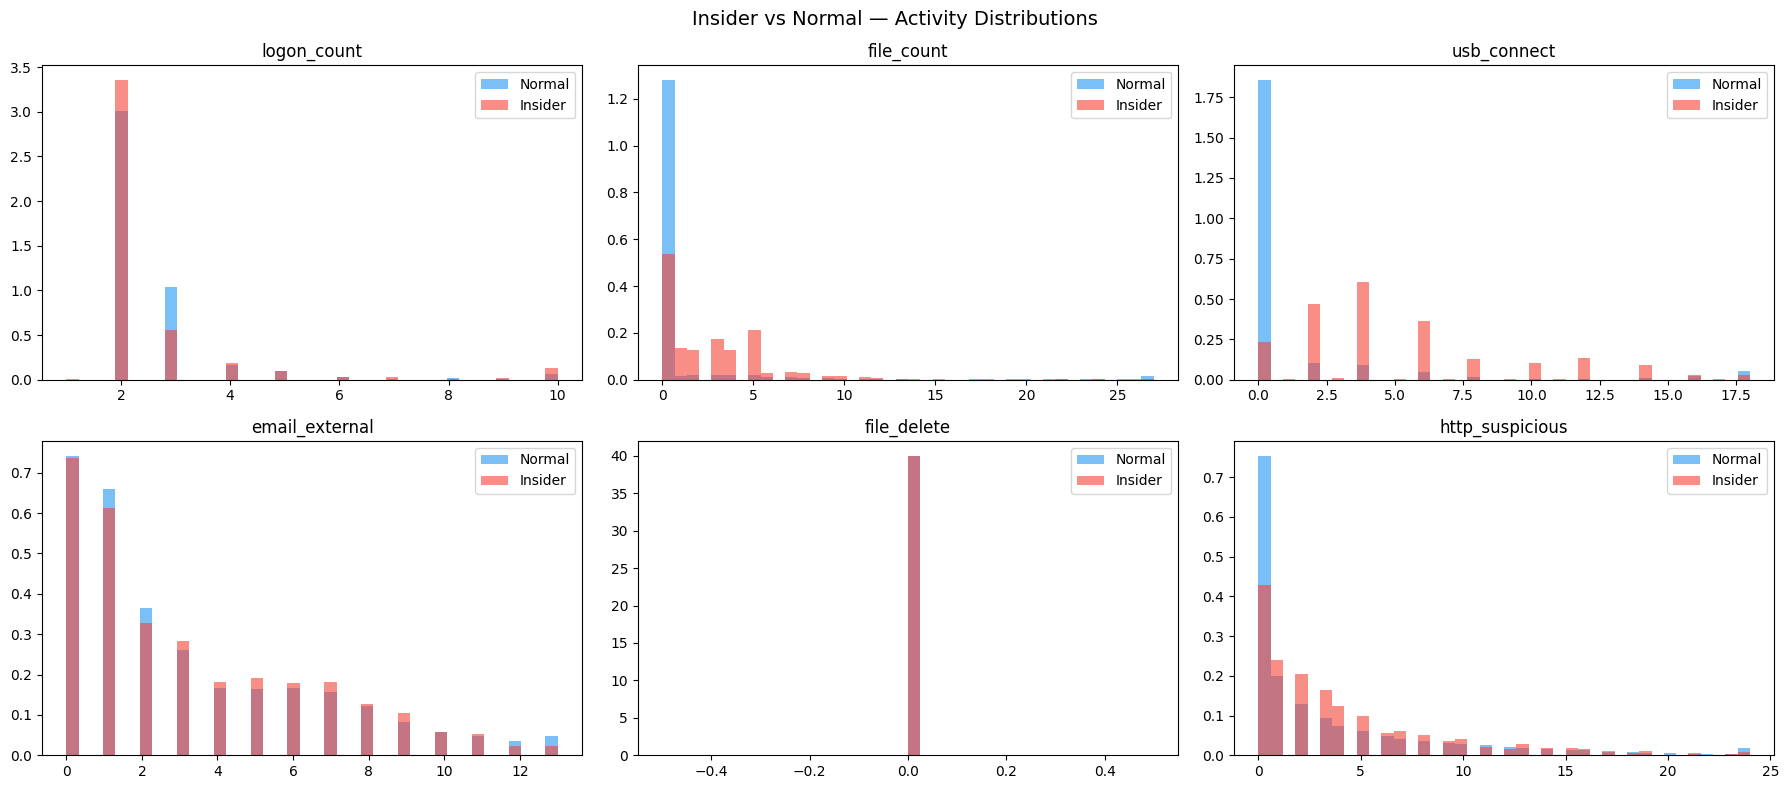

In [17]:
plot_cols = ["logon_count","file_count","usb_connect","email_external","file_delete","http_suspicious"]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.flat, plot_cols):
    if col not in feat_pd: ax.set_visible(False); continue
    for lbl, color, name in [(0,"#2196F3","Normal"), (1,"#F44336","Insider")]:
        vals = feat_pd[feat_pd["label"]==lbl][col].clip(upper=feat_pd[col].quantile(0.99))
        ax.hist(vals, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(col); ax.legend()
plt.suptitle("Insider vs Normal — Activity Distributions", fontsize=14)
plt.tight_layout(); plt.savefig("outputs/plots/eda.png", dpi=150); plt.show()

In [18]:
feat_pd = feat_pd.sort_values("date_only")
cutoff  = feat_pd["date_only"].quantile(0.70)
train_df = feat_pd[feat_pd["date_only"] < cutoff]
test_df  = feat_pd[feat_pd["date_only"] >= cutoff]

EXCLUDE = {"user","date_only","dt","label","scenario"}
FEATURE_COLS = [c for c in feat_pd.columns
                if c not in EXCLUDE and pd.api.types.is_numeric_dtype(feat_pd[c])]

X_train = train_df[FEATURE_COLS].fillna(0).values.astype(np.float32)
y_train = train_df["label"].values.astype(np.int32)
X_test  = test_df[FEATURE_COLS].fillna(0).values.astype(np.float32)
y_test  = test_df["label"].values.astype(np.int32)

scale_pos_weight = (y_train==0).sum() / max((y_train==1).sum(), 1)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | scale_pos_weight: {scale_pos_weight:.1f}")
print(f"Cutoff: {cutoff}")

Train: 230,767 | Test: 99,685 | scale_pos_weight: 247.9
Cutoff: 2010-12-06 00:00:00


In [19]:
# ============================================================
if (y_train==1).sum() >= 6:
    smoteenn = SMOTEENN(
        smote=SMOTE(sampling_strategy=0.2, random_state=42, k_neighbors=min(5,(y_train==1).sum()-1)),
        enn=EditedNearestNeighbours(sampling_strategy="majority"),
        random_state=42
    )
    X_bal, y_bal = smoteenn.fit_resample(X_train, y_train)
    print(f"SMOTEENN: {len(X_train):,} → {len(X_bal):,}  |  Insider: {y_bal.sum():,}")
else:
    X_bal, y_bal = X_train, y_train
    print("⚠️  Too few insiders — using original data")


SMOTEENN: 230,767 → 275,008  |  Insider: 45,968


In [20]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    tree_method="hist",
    device="cuda",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_bal, y_bal, eval_set=[(X_test, y_test)], verbose=50)
print(f"✅ XGBoost done | best_iteration: {xgb_model.best_iteration}")

[0]	validation_0-aucpr:0.02081


[50]	validation_0-aucpr:0.17466
[100]	validation_0-aucpr:0.69752
[150]	validation_0-aucpr:0.84774
[200]	validation_0-aucpr:0.88542
[250]	validation_0-aucpr:0.91170
[300]	validation_0-aucpr:0.92197
[350]	validation_0-aucpr:0.92613
[400]	validation_0-aucpr:0.92802
[450]	validation_0-aucpr:0.92818
[499]	validation_0-aucpr:0.92838
✅ XGBoost done | best_iteration: 495


In [21]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    device_type="cpu",   # LightGBM GPU needs OpenCL, not CUDA — CPU is fast enough
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(
    X_bal, y_bal,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(50)],
)
print(f"✅ LightGBM done | best_iteration: {lgb_model.best_iteration_}")


[50]	valid_0's binary_logloss: 0.0313241
[100]	valid_0's binary_logloss: 0.0205629
[150]	valid_0's binary_logloss: 0.0179594
[200]	valid_0's binary_logloss: 0.0141747
[250]	valid_0's binary_logloss: 0.0117137
[300]	valid_0's binary_logloss: 0.0116612
✅ LightGBM done | best_iteration: 274


In [22]:
xgb_prob  = xgb_model.predict_proba(X_test)[:, 1]
lgb_prob  = lgb_model.predict_proba(X_test)[:, 1]
ens_prob  = 0.55 * xgb_prob + 0.45 * lgb_prob

best_t, best_f1 = 0.5, 0.0
for t in np.arange(0.05, 0.95, 0.01):
    f1 = f1_score(y_test, (ens_prob >= t).astype(int), zero_division=0)
    if f1 > best_f1: best_f1, best_t = f1, t

y_pred = (ens_prob >= best_t).astype(int)
print(f"Best threshold: {best_t:.2f}  (F1={best_f1:.4f})")

Best threshold: 0.05  (F1=0.8795)


In [23]:
def eval_model(y_true, y_pred, y_prob, name=""):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if y_true.sum() > 0 else 0.0
    acc = (y_true == y_pred).mean()
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn + 1e-9)
    # DR at budget
    idx = np.argsort(y_prob)[::-1]
    dr5  = y_true[idx[:int(len(y_prob)*0.05)]].sum() / max(y_true.sum(), 1)
    dr10 = y_true[idx[:int(len(y_prob)*0.10)]].sum() / max(y_true.sum(), 1)
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}   (SoTA: 0.979)")
    print(f"  Precision: {p:.4f}   (SoTA: 0.933)")
    print(f"  Recall   : {r:.4f}   (SoTA: 0.987)")
    print(f"  F1       : {f1:.4f}")
    print(f"  AUC-ROC  : {auc:.4f}")
    print(f"  FPR      : {fpr:.4f}   (SoTA: 0.022)")
    print(f"  DR@5%%   : {dr5:.4f}")
    print(f"  DR@10%%  : {dr10:.4f}")
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    return {"name":name,"acc":acc,"prec":p,"rec":r,"f1":f1,"auc":auc,"fpr":fpr,"dr5":dr5,"dr10":dr10}

r_xgb = eval_model(y_test, xgb_model.predict(X_test), xgb_prob, "XGBoost (GPU)")
r_lgb = eval_model(y_test, lgb_model.predict(X_test), lgb_prob, "LightGBM (GPU)")
r_ens = eval_model(y_test, y_pred, ens_prob, "Ensemble XGB+LGB")


  XGBoost (GPU)
  Accuracy : 0.9989   (SoTA: 0.979)
  Precision: 0.9383   (SoTA: 0.933)
  Recall   : 0.8009   (SoTA: 0.987)
  F1       : 0.8642
  AUC-ROC  : 0.9939
  FPR      : 0.0002   (SoTA: 0.022)
  DR@5%%   : 0.9908
  DR@10%%  : 0.9908
  TN=99225  FP=23  FN=87  TP=350

  LightGBM (GPU)
  Accuracy : 0.9978   (SoTA: 0.979)
  Precision: 0.9205   (SoTA: 0.933)
  Recall   : 0.5561   (SoTA: 0.987)
  F1       : 0.6933
  AUC-ROC  : 0.9809
  FPR      : 0.0002   (SoTA: 0.022)
  DR@5%%   : 0.9748
  DR@10%%  : 0.9771
  TN=99227  FP=21  FN=194  TP=243

  Ensemble XGB+LGB
  Accuracy : 0.9990   (SoTA: 0.979)
  Precision: 0.8995   (SoTA: 0.933)
  Recall   : 0.8604   (SoTA: 0.987)
  F1       : 0.8795
  AUC-ROC  : 0.9919
  FPR      : 0.0004   (SoTA: 0.022)
  DR@5%%   : 0.9863
  DR@10%%  : 0.9908
  TN=99206  FP=42  FN=61  TP=376


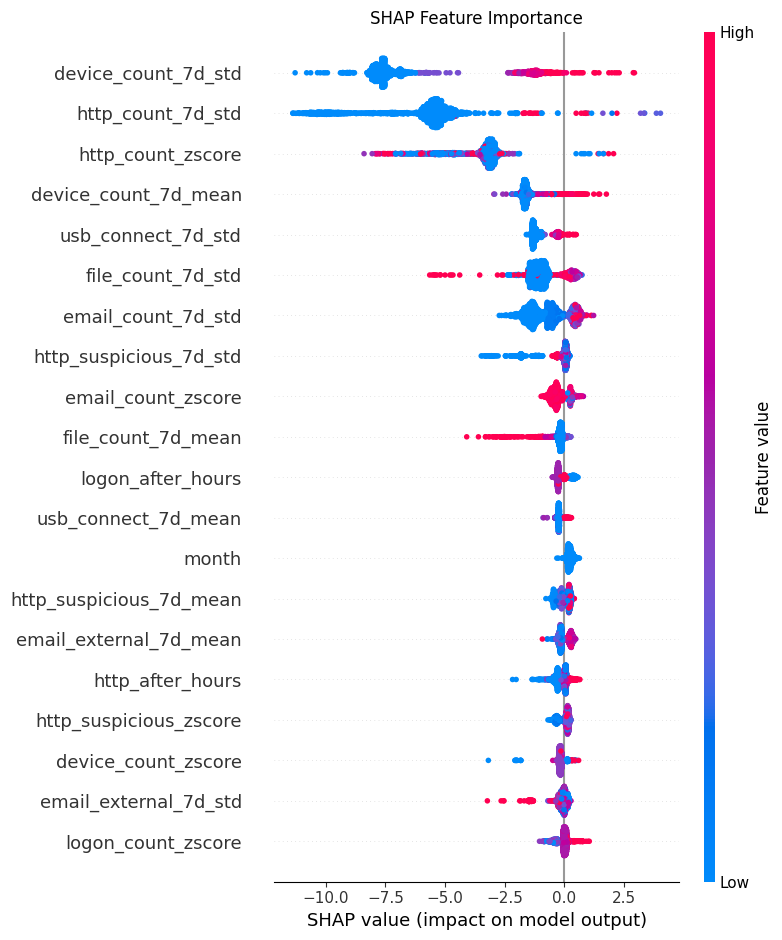

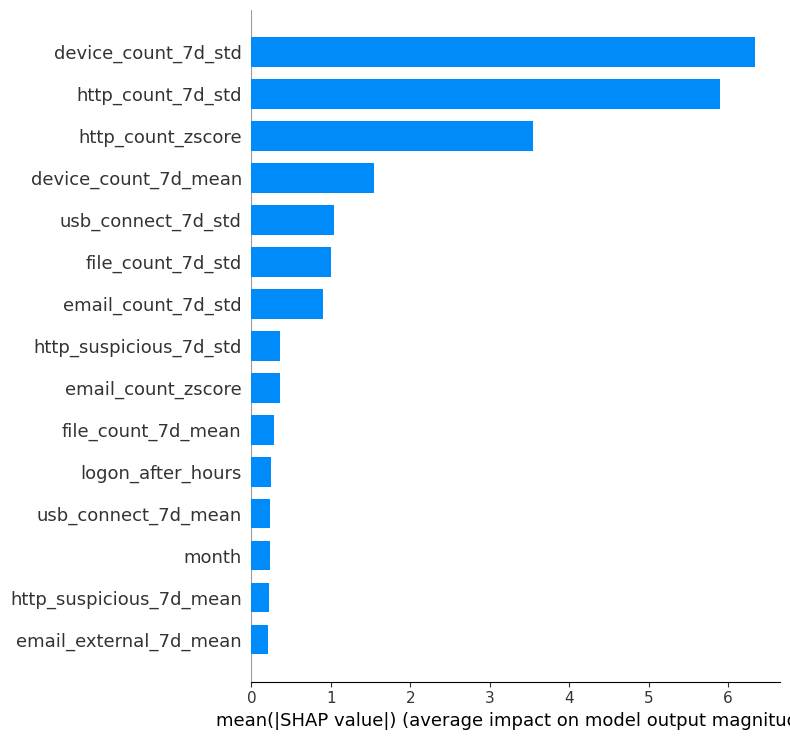

In [24]:
N_SHAP = min(2000, len(X_test))
explainer   = shap.TreeExplainer(xgb_model)
shap_vals   = explainer.shap_values(X_test[:N_SHAP])

plt.figure(figsize=(12,8))
shap.summary_plot(shap_vals, X_test[:N_SHAP], feature_names=FEATURE_COLS, max_display=20, show=False)
plt.title("SHAP Feature Importance"); plt.tight_layout()
plt.savefig("outputs/plots/shap_summary.png", dpi=150); plt.show()

plt.figure(figsize=(10,7))
shap.summary_plot(shap_vals, X_test[:N_SHAP], feature_names=FEATURE_COLS, plot_type="bar", max_display=15, show=False)
plt.tight_layout(); plt.savefig("outputs/plots/shap_bar.png", dpi=150); plt.show()

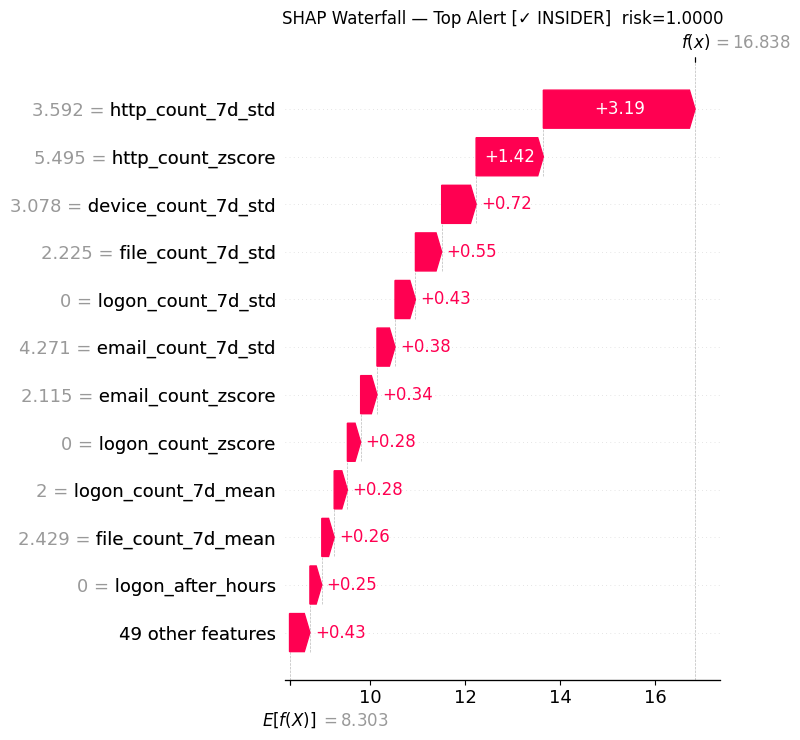

In [25]:
top_idx = np.argmax(ens_prob)
exp = shap.Explanation(
    values=shap_vals[top_idx] if top_idx < N_SHAP else shap_vals[0],
    base_values=explainer.expected_value,
    data=X_test[top_idx] if top_idx < N_SHAP else X_test[0],
    feature_names=FEATURE_COLS
)
plt.figure(figsize=(12,7))
shap.waterfall_plot(exp, max_display=12, show=False)
label_str = "✓ INSIDER" if y_test[top_idx]==1 else "✗ Normal"
plt.title(f"SHAP Waterfall — Top Alert [{label_str}]  risk={ens_prob[top_idx]:.4f}")
plt.tight_layout(); plt.savefig("outputs/plots/shap_waterfall.png", dpi=150); plt.show()

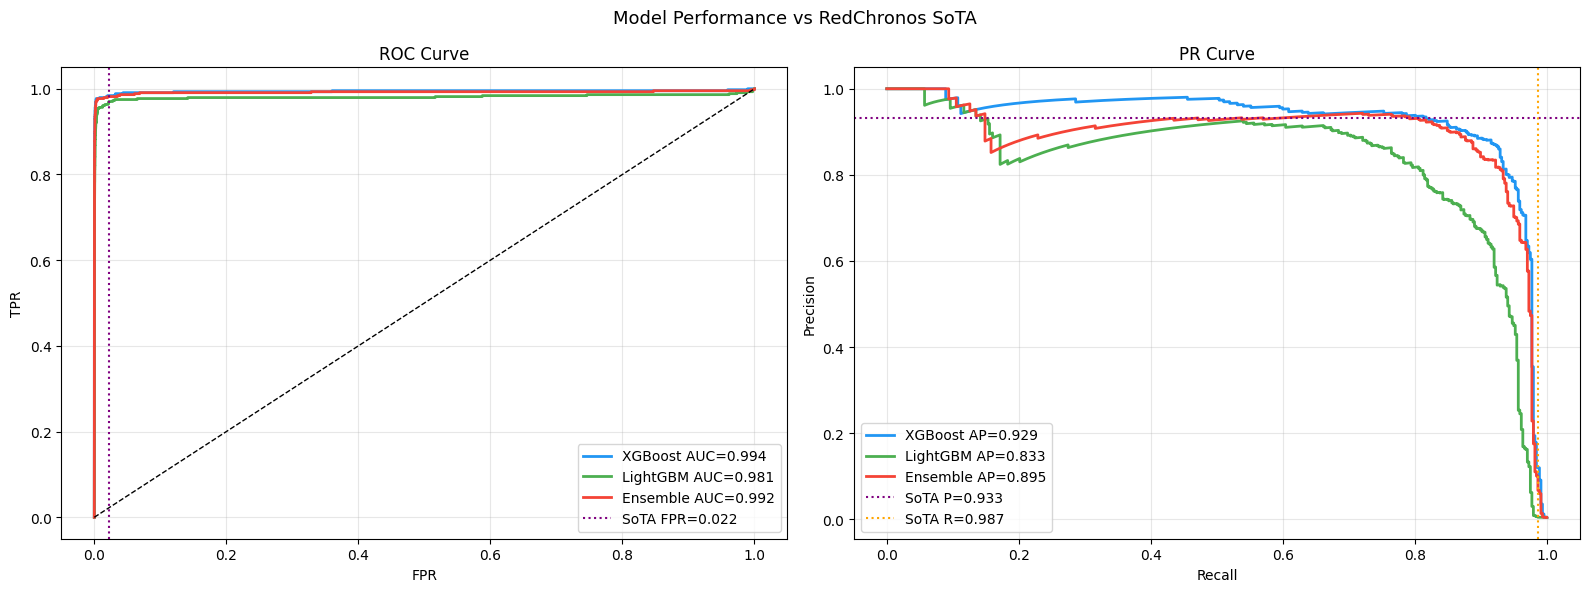

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

for prob, name, c in [(xgb_prob,"XGBoost","#2196F3"),(lgb_prob,"LightGBM","#4CAF50"),(ens_prob,"Ensemble","#F44336")]:
    if y_test.sum() == 0: continue
    fpr_v, tpr_v, _ = roc_curve(y_test, prob)
    ax1.plot(fpr_v, tpr_v, color=c, lw=2, label=f"{name} AUC={roc_auc_score(y_test,prob):.3f}")
    prec_v, rec_v, _ = precision_recall_curve(y_test, prob)
    ax2.plot(rec_v, prec_v, color=c, lw=2, label=f"{name} AP={average_precision_score(y_test,prob):.3f}")

ax1.plot([0,1],[0,1],"k--",lw=1); ax1.axvline(0.022, color='purple', ls=':', label="SoTA FPR=0.022")
ax1.set(xlabel="FPR", ylabel="TPR", title="ROC Curve"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.axhline(0.933, color='purple', ls=':', label="SoTA P=0.933")
ax2.axvline(0.987, color='orange', ls=':', label="SoTA R=0.987")
ax2.set(xlabel="Recall", ylabel="Precision", title="PR Curve"); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("Model Performance vs RedChronos SoTA", fontsize=13)
plt.tight_layout(); plt.savefig("outputs/plots/roc_pr.png", dpi=150); plt.show()

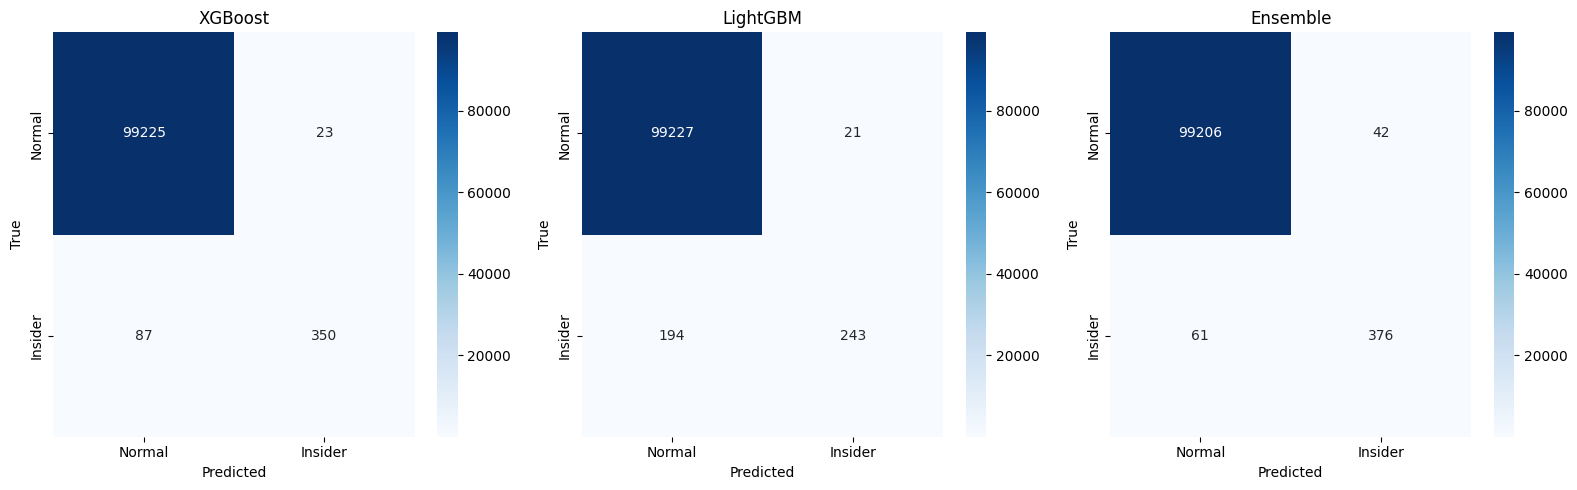

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, prob, y_p, name in zip(axes,
    [xgb_prob, lgb_prob, ens_prob],
    [xgb_model.predict(X_test), lgb_model.predict(X_test), y_pred],
    ["XGBoost", "LightGBM", "Ensemble"]
):
    sns.heatmap(confusion_matrix(y_test, y_p), annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal","Insider"], yticklabels=["Normal","Insider"])
    ax.set_title(name); ax.set_ylabel("True"); ax.set_xlabel("Predicted")
plt.tight_layout(); plt.savefig("outputs/plots/confusion.png", dpi=150); plt.show()

In [28]:
test_copy = test_df.copy().reset_index(drop=True)
test_copy["risk_score"] = ens_prob

top_users = test_copy.groupby("user")["risk_score"].mean().nlargest(20).index
hmap = (test_copy[test_copy["user"].isin(top_users)]
        .pivot_table(index="user", columns="date_only", values="risk_score", aggfunc="max").fillna(0))

fig = px.imshow(hmap.values, y=hmap.index.tolist(),
                x=[str(c)[:10] for c in hmap.columns],
                color_continuous_scale="RdYlGn_r", zmin=0, zmax=1,
                title="Risk Heatmap — Top 20 Users", height=600)
fig.update_xaxes(showticklabels=False)
fig.write_html("outputs/plots/risk_heatmap.html")
fig.show()
print("✅ Interactive heatmap saved")

✅ Interactive heatmap saved


In [29]:
test_copy["true_label"] = y_test
test_copy["pred_label"] = y_pred

top30 = test_copy.sort_values("risk_score", ascending=False).head(30)
DISP  = ["user","date_only","risk_score","true_label","pred_label",
         "logon_count","file_count","usb_connect","email_external","file_delete","http_suspicious"]
top30[[c for c in DISP if c in top30.columns]].to_csv("outputs/reports/top_alerts.csv", index=False)

print(f"Insiders in top-10: {top30.head(10)['true_label'].sum()}/10")
print(f"Insiders in top-30: {top30['true_label'].sum()}/30")
print(top30[["user","date_only","risk_score","true_label"]].head(10).to_string(index=False))

Insiders in top-10: 10/10
Insiders in top-30: 30/30
   user  date_only  risk_score  true_label
KRL0501 2010-12-07         1.0           1
IKR0401 2010-12-29         1.0           1
KRL0501 2010-12-22         1.0           1
CCL0068 2010-12-29         1.0           1
IKR0401 2010-12-27         1.0           1
KRL0501 2010-12-20         1.0           1
DRR0162 2010-12-10         1.0           1
CCL0068 2010-12-28         1.0           1
KRL0501 2010-12-21         1.0           1
KRL0501 2010-12-15         1.0           1


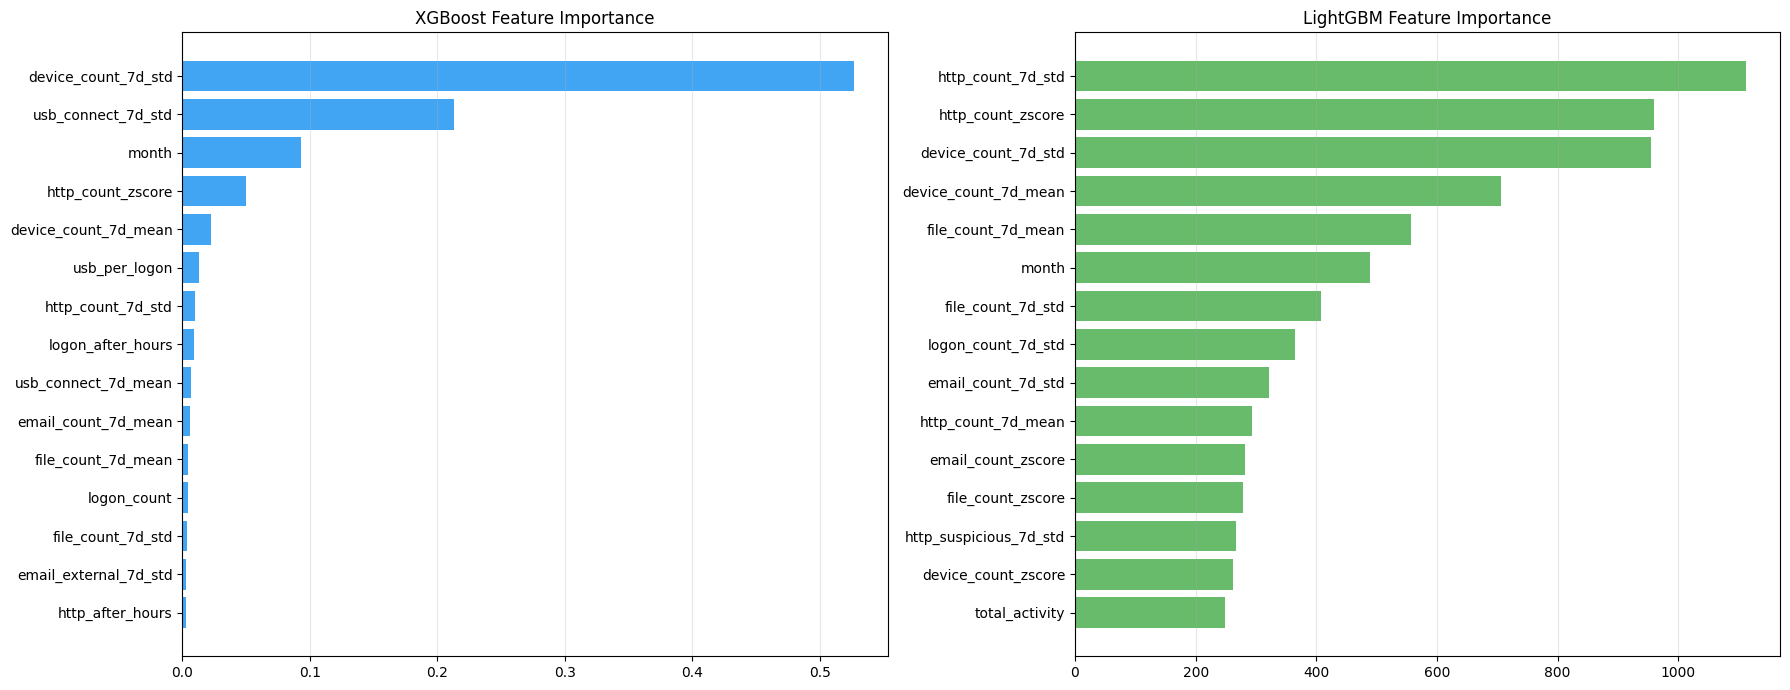

In [30]:
fi = pd.DataFrame({
    "feature": FEATURE_COLS,
    "xgb": xgb_model.feature_importances_,
    "lgb": lgb_model.feature_importances_[:len(FEATURE_COLS)],
}).sort_values("xgb", ascending=False)
fi.to_csv("outputs/reports/feature_importance.csv", index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
for ax, col, title, color in [(ax1,"xgb","XGBoost","#2196F3"),(ax2,"lgb","LightGBM","#4CAF50")]:
    top = fi.sort_values(col).tail(15)
    ax.barh(top["feature"], top[col], color=color, alpha=0.85)
    ax.set_title(f"{title} Feature Importance"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig("outputs/plots/feature_importance.png", dpi=150); plt.show()


In [31]:
pickle.dump(xgb_model, open("outputs/models/xgboost.pkl","wb"))
pickle.dump(lgb_model,  open("outputs/models/lightgbm.pkl","wb"))
print("✅ Models saved")

with open("outputs/reports/evaluation.txt","w") as f:
    f.write(f"Generated: {datetime.now()}\n\n")
    f.write("RedChronos SoTA: Prec=0.933  DR=0.987  FPR=0.022  Acc=0.979\n\n")
    for r in [r_xgb, r_lgb, r_ens]:
        f.write(f"[{r['name']}]\n")
        for k,v in r.items():
            if k != "name":
                f.write(f"  {k}: {v:.4f}\n")
        f.write("\n")

print("\n✅ DONE — outputs saved to ./outputs/")
print("="*55)
for r in [r_xgb, r_lgb, r_ens]:
    print(f"{r['name']:<25} P={r['prec']:.3f}  R={r['rec']:.3f}  FPR={r['fpr']:.3f}  AUC={r['auc']:.3f}")
print("SoTA (RedChronos)         P=0.933  R=0.987  FPR=0.022")


✅ Models saved

✅ DONE — outputs saved to ./outputs/
XGBoost (GPU)             P=0.938  R=0.801  FPR=0.000  AUC=0.994
LightGBM (GPU)            P=0.920  R=0.556  FPR=0.000  AUC=0.981
Ensemble XGB+LGB          P=0.900  R=0.860  FPR=0.000  AUC=0.992
SoTA (RedChronos)         P=0.933  R=0.987  FPR=0.022


In [33]:
!pip install google-generativeai

In [34]:
# ============================================================
# Gemini Flash Explainability Cell
# ============================================================
import google.generativeai as genai
GOOGLE_API_KEY="HERE_GOES_YOUR_MONEY"
genai.configure(api_key=GOOGLE_API_KEY)
model = genai.GenerativeModel("gemini-3-flash-preview")
def explain_prediction_with_gemini(user_id, date, features_dict, prediction_prob, top_features, shap_values):
    """
    Generates a human-readable explanation for an insider threat prediction using Gemini.
    """
    feature_importance = "\n".join([
        f"- {feat}: value={val:.4f}, SHAP impact={shap:.4f}"
        for feat, val, shap in zip(top_features['feature'], top_features['value'], top_features['shap'])
    ])
    
    prompt = f"""
You are a cybersecurity analyst specializing in insider threat detection.
A machine learning model has flagged a potential insider threat for the following user/activity:
- User: {user_id}
- Date: {date}
- Insider Probability: {prediction_prob:.2%}
- Activity Summary:
{feature_importance}
Based on the feature values and their SHAP importance values, provide a concise analysis:
1. What specific behaviors triggered this alert?
2. How severe is this risk (Low/Medium/High/Critical)?
3. What immediate actions would you recommend?
Be specific to the data provided. Keep the response under 200 words.
"""
    
    response = model.generate_content(prompt)
    return response.text
top_features_df = pd.DataFrame({
    'feature': FEATURE_COLS[:10],
    'value': X_test[top_idx][:10],
    'shap': shap_vals[top_idx][:10]
}).sort_values('shap', key=abs, ascending=False)
user_row = feat_pd.iloc[top_idx]
explanation = explain_prediction_with_gemini(
    user_id=user_row['user'],
    date=str(user_row['date_only']),
    features_dict={},
    prediction_prob=ens_prob[top_idx],
    top_features=top_features_df,
    shap_values=shap_vals[top_idx]
)
print("=" * 60)
print("GEMINI AI EXPLANATION")
print("=" * 60)
print(f"\nTop Alert - User: {user_row['user']} | Date: {user_row['date_only']}")
print(f"Predicted Insider Probability: {ens_prob[top_idx]:.4f}")
print(f"Actual Label: {'INSIDER' if y_test[top_idx]==1 else 'NORMAL'}")
print("\n" + explanation)

GEMINI AI EXPLANATION

Top Alert - User: LOM0086 | Date: 2010-01-05 00:00:00
Predicted Insider Probability: 1.0000
Actual Label: INSIDER

**Analysis for LOM0086 (2010-01-05)**

**1. Triggering Behaviors:**
The 100% probability score is driven primarily by **anomalous logon patterns**. The model flags the **absence of after-hours activity (SHAP: 0.2498)** and a **low logon frequency (2 events)** as highly suspicious relative to this user’s baseline. Crucially, the **high variability in logon timing (Std Dev: 6.36)** suggests erratic behavior. No file activity was recorded, indicating this alert focuses on account access anomalies rather than data exfiltration.

**2. Severity: High.**
While no data was moved, a 100% model confidence score indicates a total departure from the user's historical profile. This suggests either a compromised credential used for reconnaissance or a "sleeper" insider becoming active.

**3. Recommended Actions:**
*   **Identity Verification:** Compare the source 